# V2 Feature-Set Bandit Evaluation

This notebook benchmarks the feature sets generated by `src/preprocessing/preprocess_v2.ipynb` using the existing LinUCB/RidgeLinUCB implementation.

The goal is not to introduce new algorithms yet. The goal is to answer: **which V2 feature set gives the strongest contextual-bandit performance under the current RidgeLinUCB family?**

The notebook saves compact CSV summaries under `results/v2_feature_set_evaluation/`. Raw per-patient trajectories are kept in memory for metrics/plots, but are not saved by default because they can become large.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('Repository root:', REPO_ROOT)

Repository root: /Users/dhillo/Garage/codeComplete/full measure/warfarin


In [2]:
from src.bandits.linUCB import RidgeLinUCB
from src.evaluation.bandit_evaluation import plot_learning_curves
from src.evaluation.feature_set_benchmark import (
    classwise_metrics,
    confusion_table,
    evaluate_feature_set_grid,
    list_feature_sets,
    load_v2_assets,
    plot_feature_set_accuracy,
    save_benchmark_outputs,
    select_top_feature_sets,
    static_policy_summary,
    summarize_error_metrics,
)

## 1. Load V2 preprocessing outputs

This expects the files generated by the V2 preprocessing notebook under `output/preprocess_v2/`.

In [3]:
df_v2, feature_sets, preprocess_output_dir = load_v2_assets(REPO_ROOT)

print('V2 modeling table:', df_v2.shape)
print('Preprocess output directory:', preprocess_output_dir)

feature_set_summary = list_feature_sets(feature_sets)
feature_set_summary

V2 modeling table: (5528, 253)
Preprocess output directory: /Users/dhillo/Garage/codeComplete/full measure/warfarin/output/preprocess_v2


,feature_set,n_features
0,v2_expanded_regression_hw_with_indication_targ...,235
1,v2_pharmacogenetic_augmented_regression_hw,217
2,v2_strict_group_median_hw_full_dummies,213
3,v2_strict_knn_hw_full_dummies,213
4,v2_strict_regression_hw_full_dummies,213
5,v2_strict_regression_hw_drop_first,165
6,v2_iwpc_minimal_regression_hw,26


## 2. Static baseline checks

These are not bandits. They are useful horizontal references when interpreting the LinUCB/RidgeLinUCB results.

In [4]:
FEATURE_SETS = feature_set_summary['feature_set'].tolist()

static_baselines = static_policy_summary(df_v2, FEATURE_SETS)
static_baselines.sort_values(['feature_set', 'accuracy'], ascending=[True, False])

,feature_set,algorithm,accuracy,fraction_incorrect,n_correct,n_total
2,v2_expanded_regression_hw_with_indication_targ...,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,3820,5528
1,v2_expanded_regression_hw_with_indication_targ...,Clinical Formula (regression_hw),0.639110,0.360890,3533,5528
0,v2_expanded_regression_hw_with_indication_targ...,Fixed Medium Dose,0.611795,0.388205,3382,5528
20,v2_iwpc_minimal_regression_hw,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,3820,5528
19,v2_iwpc_minimal_regression_hw,Clinical Formula (regression_hw),0.639110,0.360890,3533,5528
18,v2_iwpc_minimal_regression_hw,Fixed Medium Dose,0.611795,0.388205,3382,5528
5,v2_pharmacogenetic_augmented_regression_hw,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,3820,5528
4,v2_pharmacogenetic_augmented_regression_hw,Clinical Formula (regression_hw),0.639110,0.360890,3533,5528
3,v2_pharmacogenetic_augmented_regression_hw,Fixed Medium Dose,0.611795,0.388205,3382,5528
8,v2_strict_group_median_hw_full_dummies,Pharmacogenetic Formula (group_median_hw),0.691027,0.308973,3820,5528


## 3. Stage A — screen all feature sets

This first screen uses every V2 feature set with two conservative RidgeLinUCB choices:

- `alpha = 0.0`: pure regularized greedy, no UCB exploration bonus.
- `alpha = 0.01`: close to the best setting observed earlier.
- `lambda = 10.0`: the strongest setting seen so far.

This is intentionally much cheaper than running a large alpha/lambda grid for every feature set.

In [5]:
RESULT_DIR = REPO_ROOT / 'results' / 'v2_feature_set_evaluation'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

SCREEN_FEATURE_SETS = FEATURE_SETS
SCREEN_ALPHAS = [0.0, 0.01]
SCREEN_LAMBDAS = [10.0]
SCREEN_SEEDS = range(5)

screen_summary, screen_results, screen_scale_stats = evaluate_feature_set_grid(
    df=df_v2,
    feature_sets=feature_sets,
    linucb_cls=RidgeLinUCB,
    feature_set_names=SCREEN_FEATURE_SETS,
    alphas=SCREEN_ALPHAS,
    lambda_regs=SCREEN_LAMBDAS,
    seeds=SCREEN_SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

screen_summary.head(20)

Preparing feature set: v2_expanded_regression_hw_with_indication_target_inr
  Running RidgeLinUCB(alpha=0.0, lambda=10.0) with 5 seeds...
  Running RidgeLinUCB(alpha=0.01, lambda=10.0) with 5 seeds...
Preparing feature set: v2_pharmacogenetic_augmented_regression_hw
  Running RidgeLinUCB(alpha=0.0, lambda=10.0) with 5 seeds...
  Running RidgeLinUCB(alpha=0.01, lambda=10.0) with 5 seeds...
Preparing feature set: v2_strict_group_median_hw_full_dummies
  Running RidgeLinUCB(alpha=0.0, lambda=10.0) with 5 seeds...
  Running RidgeLinUCB(alpha=0.01, lambda=10.0) with 5 seeds...
Preparing feature set: v2_strict_knn_hw_full_dummies
  Running RidgeLinUCB(alpha=0.0, lambda=10.0) with 5 seeds...
  Running RidgeLinUCB(alpha=0.01, lambda=10.0) with 5 seeds...
Preparing feature set: v2_strict_regression_hw_full_dummies
  Running RidgeLinUCB(alpha=0.0, lambda=10.0) with 5 seeds...
  Running RidgeLinUCB(alpha=0.01, lambda=10.0) with 5 seeds...
Preparing feature set: v2_strict_regression_hw_drop_first


,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,feature_set,alpha,lambda_reg,n_features
2,"RidgeLinUCB(alpha=0.0, lambda=10.0)",5,0.674457,0.004290,1799.6,23.712866,0.325543,0.004290,0.6868,0.021005,0.003760,20.785243,0.003760,0.018411,v2_pharmacogenetic_augmented_regression_hw,0.00,10.0,217
3,"RidgeLinUCB(alpha=0.01, lambda=10.0)",5,0.670369,0.008461,1822.2,46.772855,0.329631,0.008461,0.6884,0.020169,0.007416,40.998215,0.007416,0.017679,v2_pharmacogenetic_augmented_regression_hw,0.01,10.0,217
8,"RidgeLinUCB(alpha=0.0, lambda=10.0)",5,0.669863,0.001260,1825.0,6.964194,0.330137,0.001260,0.6856,0.020169,0.001104,6.104385,0.001104,0.017679,v2_strict_regression_hw_full_dummies,0.00,10.0,213
6,"RidgeLinUCB(alpha=0.0, lambda=10.0)",5,0.669501,0.004481,1827.0,24.768932,0.330499,0.004481,0.6880,0.015811,0.003927,21.710926,0.003927,0.013859,v2_strict_knn_hw_full_dummies,0.00,10.0,213
0,"RidgeLinUCB(alpha=0.0, lambda=10.0)",5,0.669284,0.003121,1828.2,17.253985,0.330716,0.003121,0.6856,0.018188,0.002736,15.123785,0.002736,0.015942,v2_expanded_regression_hw_with_indication_targ...,0.00,10.0,235
4,"RidgeLinUCB(alpha=0.0, lambda=10.0)",5,0.669175,0.002884,1828.8,15.943651,0.330825,0.002884,0.6828,0.015073,0.002528,13.975226,0.002528,0.013212,v2_strict_group_median_hw_full_dummies,0.00,10.0,213
10,"RidgeLinUCB(alpha=0.0, lambda=10.0)",5,0.663278,0.005056,1861.4,27.951744,0.336722,0.005056,0.6876,0.017967,0.004432,24.500784,0.004432,0.015748,v2_strict_regression_hw_drop_first,0.00,10.0,165
1,"RidgeLinUCB(alpha=0.01, lambda=10.0)",5,0.657779,0.025886,1891.8,143.096820,0.342221,0.025886,0.6656,0.047231,0.022690,125.429893,0.022690,0.041400,v2_expanded_regression_hw_with_indication_targ...,0.01,10.0,235
5,"RidgeLinUCB(alpha=0.01, lambda=10.0)",5,0.648263,0.026757,1944.4,147.913150,0.351737,0.026757,0.6672,0.026329,0.023454,129.651593,0.023454,0.023078,v2_strict_group_median_hw_full_dummies,0.01,10.0,213
9,"RidgeLinUCB(alpha=0.01, lambda=10.0)",5,0.647685,0.026266,1947.6,145.195730,0.352315,0.026266,0.6684,0.026207,0.023023,127.269669,0.023023,0.022971,v2_strict_regression_hw_full_dummies,0.01,10.0,213


In [6]:
screen_error_summary = summarize_error_metrics(screen_results)
screen_classwise = classwise_metrics(screen_results)
screen_confusion = confusion_table(screen_results, normalize='true')

written = save_benchmark_outputs(
    RESULT_DIR / 'screen_all_feature_sets',
    static_baselines=static_baselines,
    screen_summary=screen_summary,
    screen_error_summary=screen_error_summary,
    screen_classwise=screen_classwise,
    screen_confusion_true_normalized=screen_confusion,
    screen_scale_stats=screen_scale_stats,
)
written

{'static_baselines': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/screen_all_feature_sets/static_baselines.csv',
 'screen_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/screen_all_feature_sets/screen_summary.csv',
 'screen_error_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/screen_all_feature_sets/screen_error_summary.csv',
 'screen_classwise': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/screen_all_feature_sets/screen_classwise.csv',
 'screen_confusion_true_normalized': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/screen_all_feature_sets/screen_confusion_true_normalized.csv',
 'screen_scale_stats': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/screen_all_feature_sets/screen_scale_stats.csv'}

In [7]:
screen_error_summary.head(20)

,feature_set,algorithm,alpha,lambda_reg,n_runs,accuracy_mean,accuracy_std,severe_error_rate_mean,severe_error_rate_std,one_step_error_rate_mean,underdose_rate_mean,overdose_rate_mean,accuracy_ci95,severe_error_rate_ci95
4,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,5,0.674457,0.004290,0.002026,0.000432,0.323517,0.175687,0.149855,0.003760,0.000379
5,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.01, lambda=10.0)",0.01,10.0,5,0.670369,0.008461,0.001375,0.000835,0.328256,0.165087,0.164544,0.007416,0.000732
12,v2_strict_regression_hw_full_dummies,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,5,0.669863,0.001260,0.002135,0.000268,0.328003,0.175145,0.154993,0.001104,0.000235
8,v2_strict_knn_hw_full_dummies,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,5,0.669501,0.004481,0.002243,0.000537,0.328256,0.177135,0.153365,0.003927,0.000470
0,v2_expanded_regression_hw_with_indication_targ...,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,5,0.669284,0.003121,0.001954,0.000324,0.328763,0.177352,0.153365,0.002736,0.000284
6,v2_strict_group_median_hw_full_dummies,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,5,0.669175,0.002884,0.002207,0.000502,0.328618,0.176339,0.154486,0.002528,0.000440
10,v2_strict_regression_hw_drop_first,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,5,0.663278,0.005056,0.001954,0.000619,0.334768,0.174819,0.161903,0.004432,0.000542
1,v2_expanded_regression_hw_with_indication_targ...,"RidgeLinUCB(alpha=0.01, lambda=10.0)",0.01,10.0,5,0.657779,0.025886,0.001809,0.001078,0.340412,0.160781,0.181440,0.022690,0.000945
7,v2_strict_group_median_hw_full_dummies,"RidgeLinUCB(alpha=0.01, lambda=10.0)",0.01,10.0,5,0.648263,0.026757,0.001158,0.001105,0.350579,0.152243,0.199493,0.023454,0.000968
13,v2_strict_regression_hw_full_dummies,"RidgeLinUCB(alpha=0.01, lambda=10.0)",0.01,10.0,5,0.647685,0.026266,0.001085,0.001165,0.351230,0.150941,0.201375,0.023023,0.001021


In [8]:
screen_classwise.sort_values(
    ['feature_set', 'algorithm', 'lambda_reg', 'alpha', 'class_id']
).head(30)

,feature_set,algorithm,alpha,lambda_reg,class_id,class_name,n_runs,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support_mean,recall_ci95,f1_ci95
0,v2_expanded_regression_hw_with_indication_targ...,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,0,low,5,0.656004,0.010878,0.438261,0.010570,0.525380,0.008192,1495.0,0.009265,0.007180
1,v2_expanded_regression_hw_with_indication_targ...,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,1,medium,5,0.673309,0.002607,0.898699,0.006917,0.769833,0.002690,3382.0,0.006063,0.002358
2,v2_expanded_regression_hw_with_indication_targ...,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,2,high,5,0.076471,0.170993,0.007988,0.017861,0.014465,0.032344,651.0,0.015656,0.028350
3,v2_expanded_regression_hw_with_indication_targ...,"RidgeLinUCB(alpha=0.01, lambda=10.0)",0.01,10.0,0,low,5,0.532804,0.298012,0.340870,0.191399,0.415439,0.232458,1495.0,0.167769,0.203758
4,v2_expanded_regression_hw_with_indication_targ...,"RidgeLinUCB(alpha=0.01, lambda=10.0)",0.01,10.0,1,medium,5,0.660807,0.027513,0.920580,0.046281,0.768119,0.005974,3382.0,0.040567,0.005236
5,v2_expanded_regression_hw_with_indication_targ...,"RidgeLinUCB(alpha=0.01, lambda=10.0)",0.01,10.0,2,high,5,0.152254,0.208576,0.020276,0.028103,0.035751,0.049444,651.0,0.024633,0.043340
6,v2_iwpc_minimal_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,0,low,5,0.354240,0.289667,0.136990,0.186731,0.181608,0.246884,1495.0,0.163677,0.216403
7,v2_iwpc_minimal_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,1,medium,5,0.630126,0.025349,0.969722,0.039219,0.762929,0.006042,3382.0,0.034377,0.005296
8,v2_iwpc_minimal_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.00,10.0,2,high,5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,651.0,0.000000,0.000000
9,v2_iwpc_minimal_regression_hw,"RidgeLinUCB(alpha=0.01, lambda=10.0)",0.01,10.0,0,low,5,0.133333,0.298142,0.070100,0.156749,0.091890,0.205471,1495.0,0.137397,0.180103


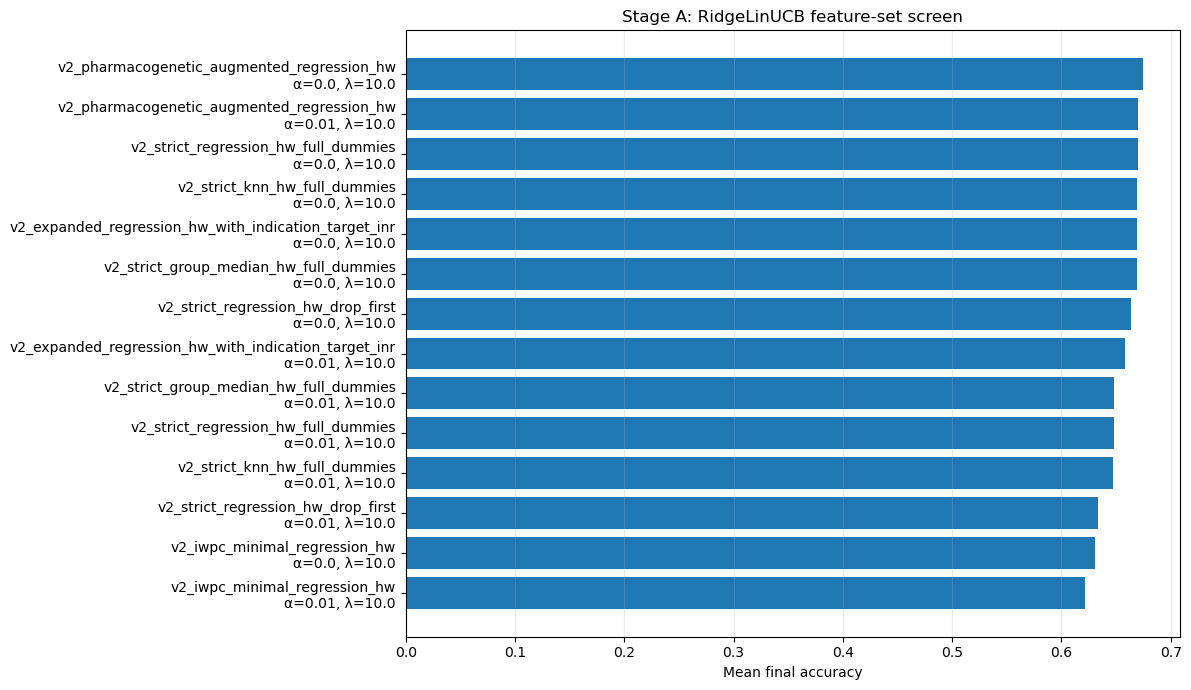

In [9]:
fig, ax = plot_feature_set_accuracy(
    screen_summary,
    top_n=20,
    title='Stage A: RidgeLinUCB feature-set screen'
)
plt.show()

## 4. Stage B — local tuning on the top feature sets

After the broad screen, we tune only the strongest feature sets. This keeps the experiment tractable while still testing the important question: **does `alpha=0` win, or does a small UCB bonus still help?**

You can increase `TOP_N_FEATURE_SETS`, `LOCAL_SEEDS`, `LOCAL_ALPHAS`, or `LOCAL_LAMBDAS` later if needed.

In [10]:
TOP_N_FEATURE_SETS = 2
TOP_FEATURE_SETS = select_top_feature_sets(screen_summary, top_n=TOP_N_FEATURE_SETS)
TOP_FEATURE_SETS

['v2_pharmacogenetic_augmented_regression_hw',
 'v2_strict_regression_hw_full_dummies']

In [11]:
RUN_LOCAL_GRID = True

LOCAL_ALPHAS = [0.0, 0.001, 0.005, 0.01, 0.025, 0.05, 0.1]
LOCAL_LAMBDAS = [5.0, 10.0, 20.0]
LOCAL_SEEDS = range(3)

if RUN_LOCAL_GRID:
    local_summary, local_results, local_scale_stats = evaluate_feature_set_grid(
        df=df_v2,
        feature_sets=feature_sets,
        linucb_cls=RidgeLinUCB,
        feature_set_names=TOP_FEATURE_SETS,
        alphas=LOCAL_ALPHAS,
        lambda_regs=LOCAL_LAMBDAS,
        seeds=LOCAL_SEEDS,
        standardize=True,
        progress=False,
        verbose=True,
    )
else:
    local_summary = pd.DataFrame()
    local_results = pd.DataFrame()
    local_scale_stats = pd.DataFrame()

local_summary.head(20)

Preparing feature set: v2_pharmacogenetic_augmented_regression_hw
  Running RidgeLinUCB(alpha=0.0, lambda=5.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.0, lambda=10.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.0, lambda=20.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.001, lambda=5.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.001, lambda=10.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.001, lambda=20.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.005, lambda=5.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.005, lambda=10.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.005, lambda=20.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.01, lambda=5.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.01, lambda=10.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.01, lambda=20.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.025, lambda=5.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.025, lambda=10.0) with 3 seeds...
  Running RidgeLinUCB(alpha=0.025, lambda=20.0) with

,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,feature_set,alpha,lambda_reg,n_features
19,"RidgeLinUCB(alpha=0.1, lambda=10.0)",3,0.680535,0.004619,1766.000000,25.534291,0.319465,0.004619,0.690000,0.032741,0.005227,28.894770,0.005227,0.037050,v2_pharmacogenetic_augmented_regression_hw,0.100,10.0,217
12,"RidgeLinUCB(alpha=0.025, lambda=5.0)",3,0.679510,0.005739,1771.666667,31.722757,0.320490,0.005739,0.694000,0.023065,0.006494,35.897679,0.006494,0.026101,v2_pharmacogenetic_augmented_regression_hw,0.025,5.0,217
16,"RidgeLinUCB(alpha=0.05, lambda=10.0)",3,0.678787,0.006082,1775.666667,33.620430,0.321213,0.006082,0.688000,0.034176,0.006882,38.045098,0.006882,0.038674,v2_pharmacogenetic_augmented_regression_hw,0.050,10.0,217
0,"RidgeLinUCB(alpha=0.0, lambda=5.0)",3,0.678365,0.002086,1778.000000,11.532563,0.321635,0.002086,0.693333,0.033126,0.002361,13.050323,0.002361,0.037486,v2_pharmacogenetic_augmented_regression_hw,0.000,5.0,217
18,"RidgeLinUCB(alpha=0.1, lambda=5.0)",3,0.678184,0.002507,1779.000000,13.856406,0.321816,0.002507,0.695333,0.026102,0.002836,15.680000,0.002836,0.029538,v2_pharmacogenetic_augmented_regression_hw,0.100,5.0,217
9,"RidgeLinUCB(alpha=0.01, lambda=5.0)",3,0.677340,0.002469,1783.666667,13.650397,0.322660,0.002469,0.693333,0.033005,0.002794,15.446878,0.002794,0.037349,v2_pharmacogenetic_augmented_regression_hw,0.010,5.0,217
6,"RidgeLinUCB(alpha=0.005, lambda=5.0)",3,0.677219,0.002097,1784.333333,11.590226,0.322781,0.002097,0.687333,0.035005,0.002373,13.115575,0.002373,0.039612,v2_pharmacogenetic_augmented_regression_hw,0.005,5.0,217
20,"RidgeLinUCB(alpha=0.1, lambda=20.0)",3,0.676918,0.006500,1786.000000,35.930488,0.323082,0.006500,0.689333,0.027006,0.007355,40.659175,0.007355,0.030560,v2_pharmacogenetic_augmented_regression_hw,0.100,20.0,217
1,"RidgeLinUCB(alpha=0.0, lambda=10.0)",3,0.676495,0.002158,1788.333333,11.930353,0.323505,0.002158,0.688000,0.028213,0.002442,13.500466,0.002442,0.031927,v2_pharmacogenetic_augmented_regression_hw,0.000,10.0,217
15,"RidgeLinUCB(alpha=0.05, lambda=5.0)",3,0.676194,0.004587,1790.000000,25.357445,0.323806,0.004587,0.690667,0.021197,0.005191,28.694650,0.005191,0.023987,v2_pharmacogenetic_augmented_regression_hw,0.050,5.0,217


In [12]:
if RUN_LOCAL_GRID:
    local_error_summary = summarize_error_metrics(local_results)
    local_classwise = classwise_metrics(local_results)
    local_confusion = confusion_table(local_results, normalize='true')

    written = save_benchmark_outputs(
        RESULT_DIR / 'local_grid_top_feature_sets',
        local_summary=local_summary,
        local_error_summary=local_error_summary,
        local_classwise=local_classwise,
        local_confusion_true_normalized=local_confusion,
        local_scale_stats=local_scale_stats,
    )
    written
else:
    print('Local grid skipped.')

In [13]:
if RUN_LOCAL_GRID:
    display(local_error_summary.head(20))

,feature_set,algorithm,alpha,lambda_reg,n_runs,accuracy_mean,accuracy_std,severe_error_rate_mean,severe_error_rate_std,one_step_error_rate_mean,underdose_rate_mean,overdose_rate_mean,accuracy_ci95,severe_error_rate_ci95
18,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.100,10.0,3,0.680535,0.004619,0.002713,0.000652,0.316751,0.158587,0.160878,0.005227,0.000738
14,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.025, lambda=5.0)",0.025,5.0,3,0.679510,0.005739,0.002593,0.000104,0.317897,0.164737,0.155753,0.006494,0.000118
15,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=10.0)",0.050,10.0,3,0.678787,0.006082,0.001688,0.000377,0.319525,0.164677,0.156536,0.006882,0.000426
2,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=5.0)",0.000,5.0,3,0.678365,0.002086,0.002774,0.000685,0.318862,0.162747,0.158888,0.002361,0.000775
20,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=5.0)",0.100,5.0,3,0.678184,0.002507,0.003437,0.000829,0.318379,0.161602,0.160215,0.002836,0.000938
11,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.01, lambda=5.0)",0.010,5.0,3,0.677340,0.002469,0.002412,0.000418,0.320248,0.161782,0.160878,0.002794,0.000473
8,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.005, lambda=5.0)",0.005,5.0,3,0.677219,0.002097,0.002171,0.000957,0.320610,0.162747,0.160034,0.002373,0.001083
19,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=20.0)",0.100,20.0,3,0.676918,0.006500,0.001869,0.000553,0.321213,0.165702,0.157381,0.007355,0.000625
0,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.000,10.0,3,0.676495,0.002158,0.001749,0.000104,0.321756,0.174626,0.148878,0.002442,0.000118
17,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=5.0)",0.050,5.0,3,0.676194,0.004587,0.002955,0.000418,0.320851,0.165762,0.158044,0.005191,0.000473


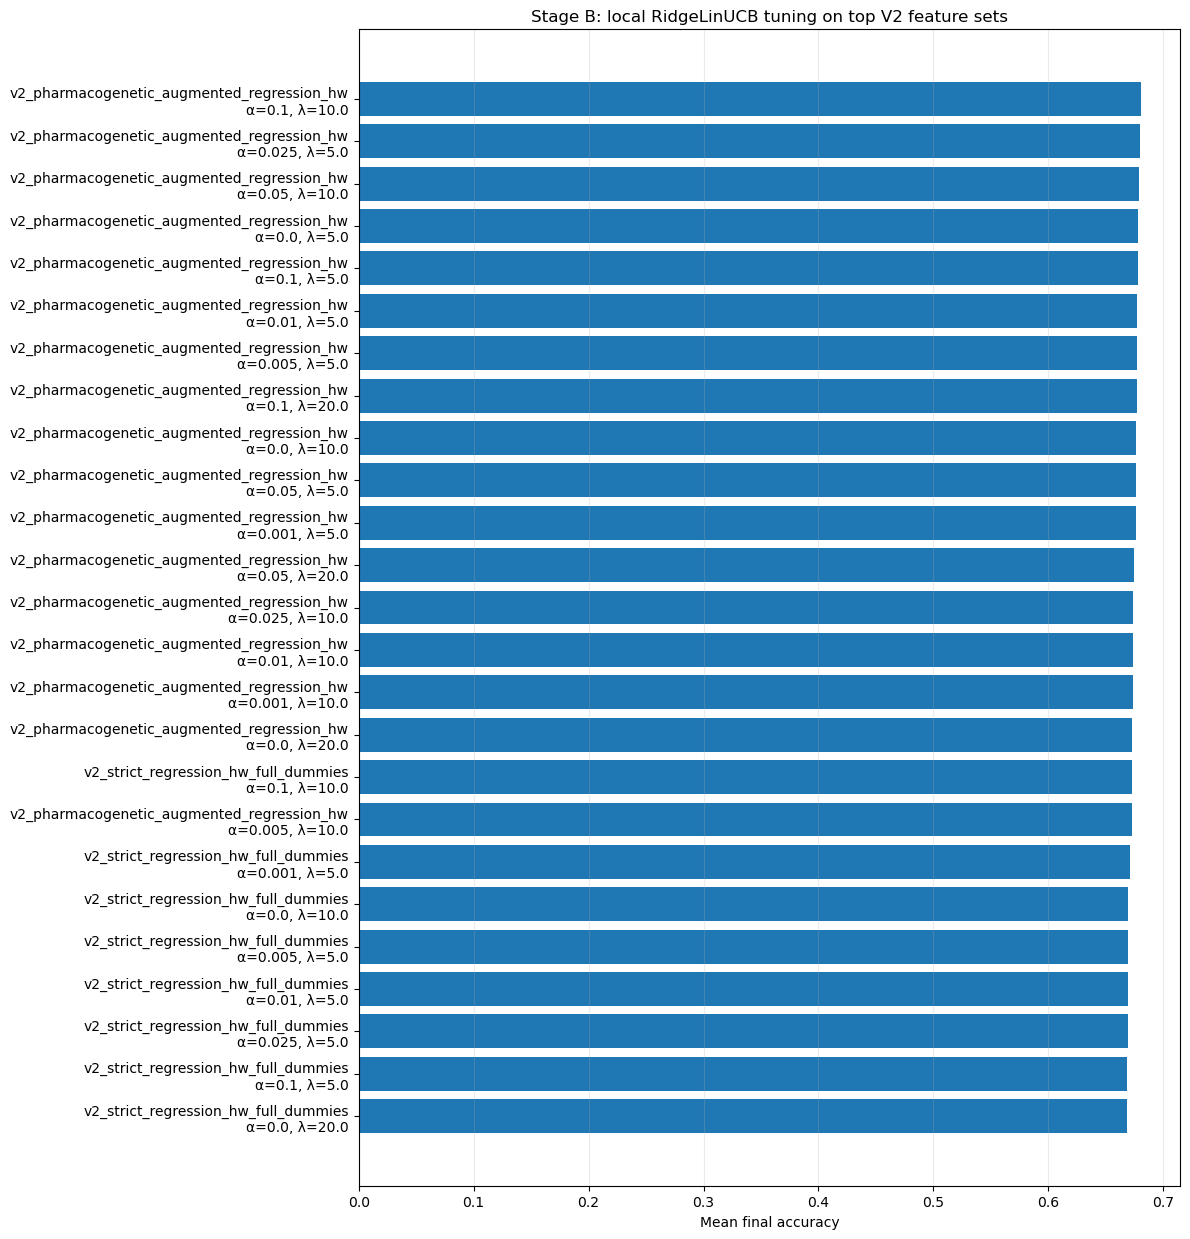

In [14]:
if RUN_LOCAL_GRID:
    fig, ax = plot_feature_set_accuracy(
        local_summary,
        top_n=25,
        title='Stage B: local RidgeLinUCB tuning on top V2 feature sets'
    )
    plt.show()

## 5. Learning curves for the best local setting

This plot is useful for seeing whether the feature set is improving mostly early, late, or across the full online trajectory.

feature_set            v2_pharmacogenetic_augmented_regression_hw
algorithm                     RidgeLinUCB(alpha=0.1, lambda=10.0)
alpha                                                         0.1
lambda_reg                                                   10.0
final_accuracy_mean                                      0.680535
late_accuracy_mean                                           0.69
Name: 19, dtype: object


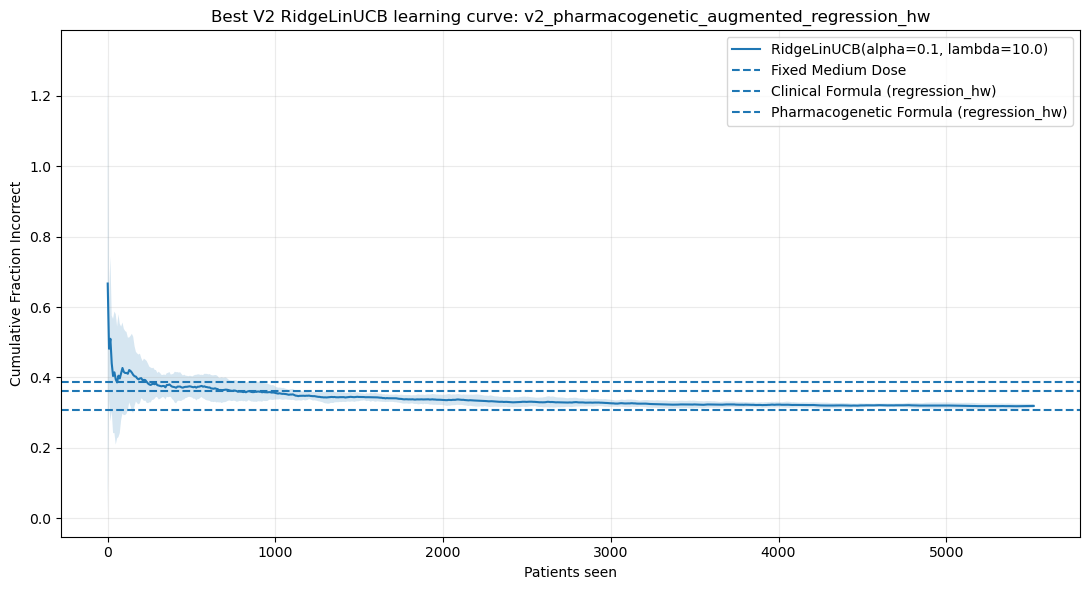

In [15]:
if RUN_LOCAL_GRID and len(local_summary):
    best = local_summary.iloc[0]
    best_results = local_results[
        (local_results['feature_set'] == best['feature_set'])
        & (local_results['alpha'] == best['alpha'])
        & (local_results['lambda_reg'] == best['lambda_reg'])
    ]
    print(best[['feature_set', 'algorithm', 'alpha', 'lambda_reg', 'final_accuracy_mean', 'late_accuracy_mean']])

    baseline_feature_set = best['feature_set']
    baseline_rows = static_baselines[static_baselines['feature_set'] == baseline_feature_set]
    baseline_rates = {
        row['algorithm']: row['fraction_incorrect']
        for _, row in baseline_rows.iterrows()
    }

    fig, ax = plot_learning_curves(
        best_results,
        metric='cumulative_fraction_incorrect',
        baseline_rates=baseline_rates,
        title=f'Best V2 RidgeLinUCB learning curve: {baseline_feature_set}',
        ci=True,
    )
    plt.show()

## 6. Final combined leaderboard

This combines Stage A and Stage B summaries. The Stage B rows are usually more reliable for the top feature sets because they search a wider local grid.

In [16]:
leaderboard_parts = [screen_summary.assign(stage='screen')]
if RUN_LOCAL_GRID and len(local_summary):
    leaderboard_parts.append(local_summary.assign(stage='local_grid'))

leaderboard = pd.concat(leaderboard_parts, ignore_index=True).sort_values(
    'final_accuracy_mean', ascending=False
)

leaderboard_path = RESULT_DIR / 'combined_feature_set_leaderboard.csv'
leaderboard.to_csv(leaderboard_path, index=False)
print('Saved:', leaderboard_path)
leaderboard.head(30)

Saved: /Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/combined_feature_set_leaderboard.csv


,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,feature_set,alpha,lambda_reg,n_features,stage
14,"RidgeLinUCB(alpha=0.1, lambda=10.0)",3,0.680535,0.004619,1766.000000,25.534291,0.319465,0.004619,0.690000,0.032741,0.005227,28.894770,0.005227,0.037050,v2_pharmacogenetic_augmented_regression_hw,0.100,10.0,217,local_grid
15,"RidgeLinUCB(alpha=0.025, lambda=5.0)",3,0.679510,0.005739,1771.666667,31.722757,0.320490,0.005739,0.694000,0.023065,0.006494,35.897679,0.006494,0.026101,v2_pharmacogenetic_augmented_regression_hw,0.025,5.0,217,local_grid
16,"RidgeLinUCB(alpha=0.05, lambda=10.0)",3,0.678787,0.006082,1775.666667,33.620430,0.321213,0.006082,0.688000,0.034176,0.006882,38.045098,0.006882,0.038674,v2_pharmacogenetic_augmented_regression_hw,0.050,10.0,217,local_grid
17,"RidgeLinUCB(alpha=0.0, lambda=5.0)",3,0.678365,0.002086,1778.000000,11.532563,0.321635,0.002086,0.693333,0.033126,0.002361,13.050323,0.002361,0.037486,v2_pharmacogenetic_augmented_regression_hw,0.000,5.0,217,local_grid
18,"RidgeLinUCB(alpha=0.1, lambda=5.0)",3,0.678184,0.002507,1779.000000,13.856406,0.321816,0.002507,0.695333,0.026102,0.002836,15.680000,0.002836,0.029538,v2_pharmacogenetic_augmented_regression_hw,0.100,5.0,217,local_grid
19,"RidgeLinUCB(alpha=0.01, lambda=5.0)",3,0.677340,0.002469,1783.666667,13.650397,0.322660,0.002469,0.693333,0.033005,0.002794,15.446878,0.002794,0.037349,v2_pharmacogenetic_augmented_regression_hw,0.010,5.0,217,local_grid
20,"RidgeLinUCB(alpha=0.005, lambda=5.0)",3,0.677219,0.002097,1784.333333,11.590226,0.322781,0.002097,0.687333,0.035005,0.002373,13.115575,0.002373,0.039612,v2_pharmacogenetic_augmented_regression_hw,0.005,5.0,217,local_grid
21,"RidgeLinUCB(alpha=0.1, lambda=20.0)",3,0.676918,0.006500,1786.000000,35.930488,0.323082,0.006500,0.689333,0.027006,0.007355,40.659175,0.007355,0.030560,v2_pharmacogenetic_augmented_regression_hw,0.100,20.0,217,local_grid
22,"RidgeLinUCB(alpha=0.0, lambda=10.0)",3,0.676495,0.002158,1788.333333,11.930353,0.323505,0.002158,0.688000,0.028213,0.002442,13.500466,0.002442,0.031927,v2_pharmacogenetic_augmented_regression_hw,0.000,10.0,217,local_grid
23,"RidgeLinUCB(alpha=0.05, lambda=5.0)",3,0.676194,0.004587,1790.000000,25.357445,0.323806,0.004587,0.690667,0.021197,0.005191,28.694650,0.005191,0.023987,v2_pharmacogenetic_augmented_regression_hw,0.050,5.0,217,local_grid


## 7. Notes for interpretation

Use the CSV outputs from this notebook to decide the next modeling direction. In particular:

1. If the pharmacogenetic-augmented feature set wins, the next algorithmic step should be warm-started or prior-informed contextual bandits.
2. If the drop-first version wins, the UCB uncertainty geometry was being hurt by redundant dummies.
3. If `alpha=0` consistently wins, the online problem is behaving more like conservative regularized online supervised learning than exploration-heavy recommendation.
4. If high-dose recall remains poor, the next patch should add class-imbalance-aware rewards or risk-sensitive regret metrics.
5. If severe error rate is materially reduced even when accuracy is similar, that feature set may be clinically preferable.